### Wifi features

This this is the code to generate the wifi features available in [this dataset](https://www.kaggle.com/devinanzelmo/indoor-navigation-and-location-wifi-features). Using these features can get a score below 14. For an example notebook using them see [this notebook](https://www.kaggle.com/devinanzelmo/wifi-features-lightgbm-starter). They only uses waypoints, wifi and timestamp data to generate solution. See this [forum post](https://www.kaggle.com/c/indoor-location-navigation/discussion/215445) for an outline of this solution method, and methods of improvement.

There are `break`'s inserted into loops which need to be removed to get this to run. Right now data is written to current working directory. This takes 2-4 hours to run depending on hard drive etc. There is a lot of room for improvement speeding up feature generation. 

**Update:** I added one line that creates a column for the path filename, this allows for a groupkfold crossvalidation. 


In [1]:
import pandas as pd
import numpy as np
import glob
import os
import gc
import json 

In [2]:
# Paths: train data and output folder for preprocessed train sites
base_path = r'C:\Users\Noa\Documents\GitHub\indoor_localization_research'
train_path = os.path.join(base_path, 'train')
output_dir = os.path.join(base_path, 'preprocessed_data_thesis', 'all train sites')
os.makedirs(output_dir, exist_ok=True)

In [3]:
# All train sites (204 total). Change START_IX and N_SITES each run to process different batches.
all_sites = sorted([d for d in os.listdir(train_path) if os.path.isdir(os.path.join(train_path, d))])
print(f"Total train sites: {len(all_sites)}")

START_IX = 0   # starting index (0, 60, 120, ...)
N_SITES = 60   # number of sites to process this run (e.g. 60)

used_buildings = all_sites[START_IX : START_IX + N_SITES]
print(f"This run: sites [{START_IX}:{START_IX + N_SITES}] = {len(used_buildings)} sites")

# dictionary used to map the floor codes to the values used in the submission file. 
floor_map = {"B2":-2, "B1":-1, "F1":0, "F2": 1, "F3":2, "F4":3, "F5":4, "F6":5, "F7":6,"F8":7, "F9":8,
             "1F":0, "2F":1, "3F":2, "4F":3, "5F":4, "6F":5, "7F":6, "8F": 7, "9F":8}

Total train sites: 204
This run: sites [0:60] = 60 sites


In [4]:
# get only the wifi bssid that occur over 1000 times (this number can be experimented with)
# these will be the only ones used when constructing features
bssid = dict()

for building in used_buildings:
    folders = sorted(glob.glob(os.path.join(train_path, building, '*')))
    print(building)
    wifi = list()
    for folder in folders:
        floor_name = os.path.basename(folder)
        if floor_name not in floor_map:
            continue
        floor = floor_map[floor_name]
        files = glob.glob(os.path.join(folder, "*.txt"))
        for file in files:
            with open(file) as f:
                txt = f.readlines()
                for e, line in enumerate(txt):
                    tmp = line.strip().split()
                    if len(tmp) > 1 and tmp[1] == "TYPE_WIFI":
                        wifi.append(tmp)
    if not wifi:
        print(f"  (no wifi data, skipping)")
        continue
    df = pd.DataFrame(wifi)
    value_counts = df[3].value_counts()
    top_bssid = value_counts[value_counts > 1000].index.tolist()
    print(len(top_bssid))
    bssid[building] = top_bssid
    del df
    del wifi
    gc.collect()

5a0546857ecc773753327266
941
5c3c44b80379370013e0fd2b
867
5cd56865eb294480de7167b6
33
5cd56b5ae2acfd2d33b58544
47
5cd56b5ae2acfd2d33b58546
85
5cd56b5ae2acfd2d33b58548
0
5cd56b5ae2acfd2d33b58549
74
5cd56b5ae2acfd2d33b5854a
25
5cd56b61e2acfd2d33b58d20
0
5cd56b63e2acfd2d33b591c2
57
5cd56b64e2acfd2d33b59246
2
5cd56b64e2acfd2d33b592b3
0
5cd56b64e2acfd2d33b5932f
463
5cd56b67e2acfd2d33b596bd
88
5cd56b6ae2acfd2d33b59c90
21
5cd56b6ae2acfd2d33b59ccb
1454
5cd56b6ae2acfd2d33b59ccc
195
5cd56b6be2acfd2d33b59d1f
0
5cd56b6ee2acfd2d33b5a247
1
5cd56b6fe2acfd2d33b5a386
77
5cd56b70e2acfd2d33b5a44e
86
5cd56b70e2acfd2d33b5a552
293
5cd56b75e2acfd2d33b5af29
2
5cd56b76e2acfd2d33b5b0be
58
5cd56b77e2acfd2d33b5b22b
12
5cd56b77e2acfd2d33b5b310
183
5cd56b79e2acfd2d33b5b74e
5
5cd56b79e2acfd2d33b5b77c
0
5cd56b7de2acfd2d33b5c14b
3
5cd56b83e2acfd2d33b5cab0
253
5cd56b86e2acfd2d33b5cf97
161
5cd56b89e2acfd2d33b5d61e
0
5cd56b89e2acfd2d33b5d759
70
5cd56b89e2acfd2d33b5d75a
0
5cd56b8be2acfd2d33b5db68
0
5cd56b8de2acfd2d33b5dd2

In [5]:
# save bssid for this batch (filename includes range so different runs don't overwrite)
bssid_path = os.path.join(output_dir, f"bssid_1000_start{START_IX}_n{N_SITES}.json")
with open(bssid_path, "w") as f:
    json.dump(bssid, f)
print(f"Saved {bssid_path}")

Saved C:\Users\Noa\Documents\GitHub\indoor_localization_research\preprocessed_data_thesis\all train sites\bssid_1000_start0_n60.json


In [6]:
# generate all the training data for this batch
building_dfs = dict()

for building in used_buildings:
    if building not in bssid:
        continue
    folders = sorted(glob.glob(os.path.join(train_path, building, '*')))
    dfs = list()
    index = sorted(bssid[building])
    print(building)
    for folder in folders:
        floor_name = os.path.basename(folder)
        if floor_name not in floor_map:
            continue
        floor = floor_map[floor_name]
        files = glob.glob(os.path.join(folder, "*.txt"))
        print(floor)
        for file in files:
            wifi = list()
            waypoint = list()
            with open(file) as f:
                txt = f.readlines()
            for line in txt:
                line = line.strip().split()
                if len(line) < 2:
                    continue
                if line[1] == "TYPE_WAYPOINT":
                    waypoint.append(line)
                if line[1] == "TYPE_WIFI":
                    wifi.append(line)

            if not wifi or not waypoint:
                continue
            df = pd.DataFrame(np.array(wifi))

            # generate a feature, and label for each wifi block
            for gid, g in df.groupby(0):
                dists = list()
                for e, k in enumerate(waypoint):
                    dist = abs(int(gid) - int(k[0]))
                    dists.append(dist)
                nearest_wp_index = np.argmin(dists)

                g = g.drop_duplicates(subset=3)
                tmp = g.iloc[:,3:5]
                feat = tmp.set_index(3).reindex(index).replace(np.nan, -999).T
                feat["x"] = float(waypoint[nearest_wp_index][2])
                feat["y"] = float(waypoint[nearest_wp_index][3])
                feat["f"] = floor
                feat["path"] = os.path.basename(file).split('.')[0]  # useful for crossvalidation
                dfs.append(feat)

    if not dfs:
        print(f"  (no data, skipping)")
        continue
    building_df = pd.concat(dfs)
    building_dfs[building] = building_df
    out_csv = os.path.join(output_dir, building + "_1000_train.csv")
    building_df.to_csv(out_csv)
    print(f"  -> {out_csv}")

5a0546857ecc773753327266
-1


C:\Users\Noa\AppData\Local\Temp\ipykernel_3684\2085243577.py:46: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  feat = tmp.set_index(3).reindex(index).replace(np.nan, -999).T
C:\Users\Noa\AppData\Local\Temp\ipykernel_3684\2085243577.py:46: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  feat = tmp.set_index(3).reindex(index).replace(np.nan, -999).T
C:\Users\Noa\AppData\Local\Temp\ipykernel_3684\2085243577.py:46: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old b

0
1
2
3
  -> C:\Users\Noa\Documents\GitHub\indoor_localization_research\preprocessed_data_thesis\all train sites\5a0546857ecc773753327266_1000_train.csv
5c3c44b80379370013e0fd2b
-1
0
1
2
3
4
  -> C:\Users\Noa\Documents\GitHub\indoor_localization_research\preprocessed_data_thesis\all train sites\5c3c44b80379370013e0fd2b_1000_train.csv
5cd56865eb294480de7167b6
0
1
2
3
4


C:\Users\Noa\AppData\Local\Temp\ipykernel_3684\2085243577.py:46: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  feat = tmp.set_index(3).reindex(index).replace(np.nan, -999).T
C:\Users\Noa\AppData\Local\Temp\ipykernel_3684\2085243577.py:46: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  feat = tmp.set_index(3).reindex(index).replace(np.nan, -999).T
C:\Users\Noa\AppData\Local\Temp\ipykernel_3684\2085243577.py:46: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old b

  -> C:\Users\Noa\Documents\GitHub\indoor_localization_research\preprocessed_data_thesis\all train sites\5cd56865eb294480de7167b6_1000_train.csv
5cd56b5ae2acfd2d33b58544
0
1
2
3
  -> C:\Users\Noa\Documents\GitHub\indoor_localization_research\preprocessed_data_thesis\all train sites\5cd56b5ae2acfd2d33b58544_1000_train.csv
5cd56b5ae2acfd2d33b58546
-1


...

  -> C:\Users\Noa\Documents\GitHub\indoor_localization_research\preprocessed_data_thesis\all train sites\5cd56babe2acfd2d33b617e3_1000_train.csv
5cd56babe2acfd2d33b61826
0
1
2
3
  -> C:\Users\Noa\Documents\GitHub\indoor_localization_research\preprocessed_data_thesis\all train sites\5cd56babe2acfd2d33b61826_1000_train.csv
5cd56babe2acfd2d33b61827
-1
0


C:\Users\Noa\AppData\Local\Temp\ipykernel_3684\2085243577.py:46: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  feat = tmp.set_index(3).reindex(index).replace(np.nan, -999).T
C:\Users\Noa\AppData\Local\Temp\ipykernel_3684\2085243577.py:46: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  feat = tmp.set_index(3).reindex(index).replace(np.nan, -999).T
C:\Users\Noa\AppData\Local\Temp\ipykernel_3684\2085243577.py:46: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old b

1
2
3
  -> C:\Users\Noa\Documents\GitHub\indoor_localization_research\preprocessed_data_thesis\all train sites\5cd56babe2acfd2d33b61827_1000_train.csv
5cd56bace2acfd2d33b618fe
0
1
2
3
4
5
6
  -> C:\Users\Noa\Documents\GitHub\indoor_localization_research\preprocessed_data_thesis\all train sites\5cd56bace2acfd2d33b618fe_1000_train.csv
5cd56bade2acfd2d33b61a61
-1
0
1
2
3
4
5
  -> C:\Users\Noa\Documents\GitHub\indoor_localization_research\preprocessed_data_thesis\all train sites\5cd56bade2acfd2d33b61a61_1000_train.csv
5cd56baee2acfd2d33b61a93
-1


C:\Users\Noa\AppData\Local\Temp\ipykernel_3684\2085243577.py:46: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  feat = tmp.set_index(3).reindex(index).replace(np.nan, -999).T
C:\Users\Noa\AppData\Local\Temp\ipykernel_3684\2085243577.py:46: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  feat = tmp.set_index(3).reindex(index).replace(np.nan, -999).T
C:\Users\Noa\AppData\Local\Temp\ipykernel_3684\2085243577.py:46: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old b

0
1
2
3
4
5
6
7
8
  -> C:\Users\Noa\Documents\GitHub\indoor_localization_research\preprocessed_data_thesis\all train sites\5cd56baee2acfd2d33b61a93_1000_train.csv


In [7]:
# Generate the features for the test set

ssubm_building_g = ssubm_df.groupby(0)
feature_dict = dict()

for gid0, g0 in ssubm_building_g:
    break
    index = sorted(bssid[g0.iloc[0,0]])
    feats = list()
    print(gid0)
    for gid,g in g0.groupby(1):

        # get all wifi time locations, 
        with open(os.path.join(base_path, 'test/' + g.iloc[0,1] + '.txt')) as f:
            txt = f.readlines()

        wifi = list()

        for line in txt:
            line = line.strip().split()
            if line[1] == "TYPE_WIFI":
                wifi.append(line)

        wifi_df = pd.DataFrame(wifi)
        wifi_points = pd.DataFrame(wifi_df.groupby(0).count().index.tolist())
        
        for timepoint in g.iloc[:,2].tolist():

            deltas = (wifi_points.astype(int) - int(timepoint)).abs()
            min_delta_idx = deltas.values.argmin()
            wifi_block_timestamp = wifi_points.iloc[min_delta_idx].values[0]
            
            wifi_block = wifi_df[wifi_df[0] == wifi_block_timestamp].drop_duplicates(subset=3)
            feat = wifi_block.set_index(3)[4].reindex(index).fillna(-999)

            feat['site_path_timestamp'] = g.iloc[0,0] + "_" + g.iloc[0,1] + "_" + timepoint
            feats.append(feat)
    feature_df = pd.concat(feats, axis=1).T
    feature_df.to_csv(gid0+"_1000_test.csv")
    feature_dict[gid0] = feature_df

NameError: name 'ssubm_df' is not defined

### Box Plot and CDF — results from results_n_labeled.csv
Plots median localization error (m) for SSL vs Manifold Matching by n_labeled.

C:\Users\Noa\AppData\Local\Temp\ipykernel_3684\3375110281.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(data_by_method, labels=methods, patch_artist=True)


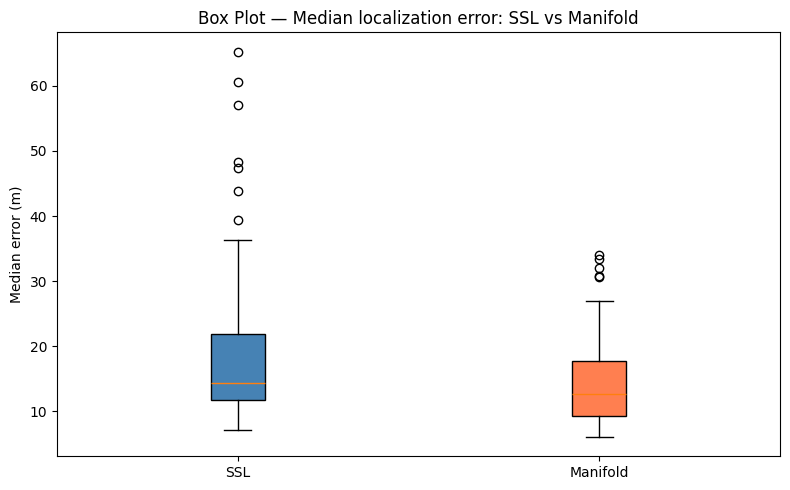

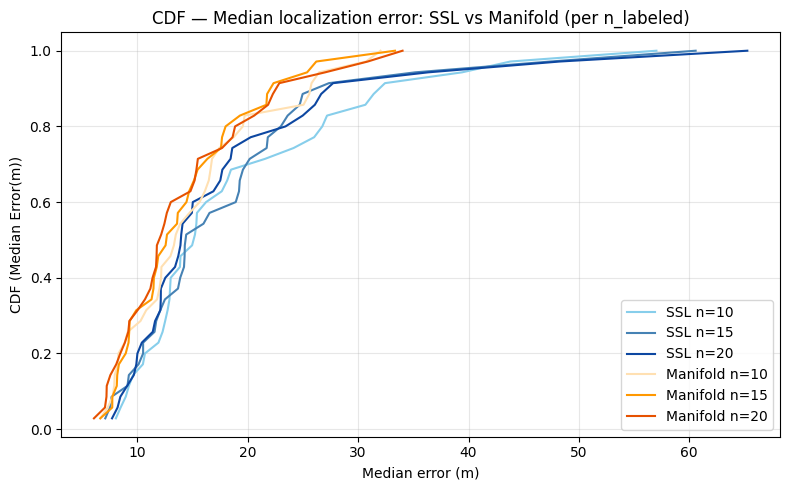

In [17]:
import matplotlib.pyplot as plt

# Path to results CSV (adjust if needed)
results_csv_path = r"C:\Users\Noa\Documents\Thesis\Outputs\experiments\n_labeled_10_15_20\results_n_labeled.csv"
df = pd.read_csv(results_csv_path)

# Ensure column names match (already: site, n_labeled, median_error_SSL_m, median_error_Manifold_m)
# Drop rows where both error columns are missing
df = df.dropna(subset=["median_error_SSL_m", "median_error_Manifold_m"], how="all")
# Convert to float in case of empty strings
df["median_error_SSL_m"] = pd.to_numeric(df["median_error_SSL_m"], errors="coerce")
df["median_error_Manifold_m"] = pd.to_numeric(df["median_error_Manifold_m"], errors="coerce")
df = df.dropna(subset=["median_error_SSL_m", "median_error_Manifold_m"], how="any")

# Long format for box plot: method (SSL / Manifold) and error value
plot_df = df.melt(
    id_vars=["site", "n_labeled"],
    value_vars=["median_error_SSL_m", "median_error_Manifold_m"],
    var_name="method",
    value_name="median_error_m"
)
# Short method labels for legend
plot_df["method"] = plot_df["method"].replace({
    "median_error_SSL_m": "SSL",
    "median_error_Manifold_m": "Manifold"
})
# For x-axis: n_labeled as category
plot_df["n_labeled"] = plot_df["n_labeled"].astype(str)

# --- 1. Box Plot ---
fig1, ax1 = plt.subplots(figsize=(8, 5))
methods = ["SSL", "Manifold"]
data_by_method = [plot_df[plot_df["method"] == m]["median_error_m"] for m in methods]
bp = ax1.boxplot(data_by_method, labels=methods, patch_artist=True)
bp["boxes"][0].set_facecolor("steelblue")
bp["boxes"][1].set_facecolor("coral")
ax1.set_ylabel("Median error (m)")
ax1.set_title("Box Plot — Median localization error: SSL vs Manifold")
plt.tight_layout()
plt.show()

# --- 2. CDF: one line per (method, n_labeled) ---
fig2, ax2 = plt.subplots(figsize=(8, 5))
# SSL = blue range (light/medium/dark for n=10,15,20), Manifold = orange range
cdf_colors = {
    "SSL": {"10": "#87CEEB", "15": "#4682B4", "20": "#0D47A1"},      # light, medium, dark blue
    "Manifold": {"10": "#FFE0B2", "15": "#FF9800", "20": "#E65100"}  # light, medium, dark orange
}
n_labeled_sorted = sorted(plot_df["n_labeled"].unique(), key=lambda x: int(x))
# Plot SSL first (all n_labeled), then Manifold (all n_labeled) so legend is grouped
for method in methods:
    for n_lab in n_labeled_sorted:
        sub = plot_df[(plot_df["method"] == method) & (plot_df["n_labeled"] == n_lab)]["median_error_m"].sort_values()
        if len(sub) == 0:
            continue
        cdf_y = np.arange(1, len(sub) + 1) / len(sub)
        color = cdf_colors[method].get(str(n_lab), "#333333")
        ax2.plot(sub.values, cdf_y, color=color, label=f"{method} n={n_lab}")
ax2.set_xlabel("Median error (m)")
ax2.set_ylabel("CDF (Median Error(m))")
ax2.set_title("CDF — Median localization error: SSL vs Manifold (per n_labeled)")
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

C:\Users\Noa\AppData\Local\Temp\ipykernel_3684\3782286518.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='N_labeled', y='Error', data=df, palette="Set2", width=0.5)


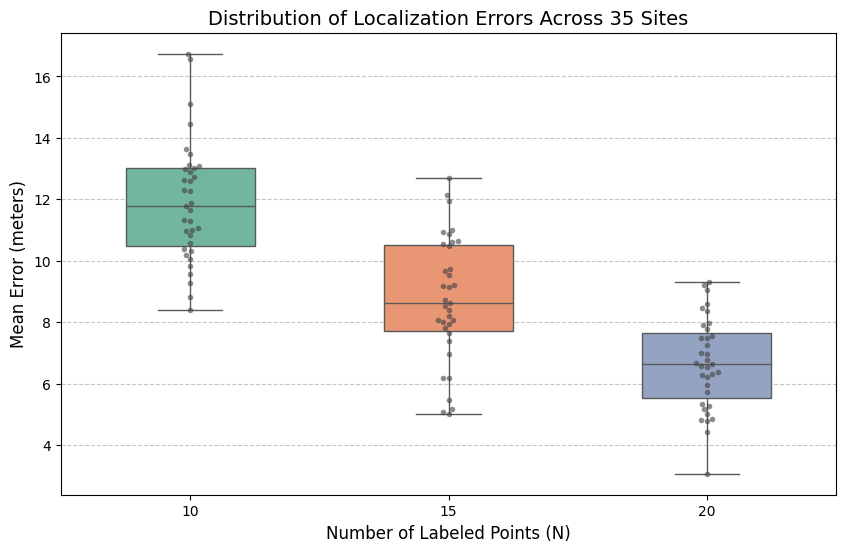

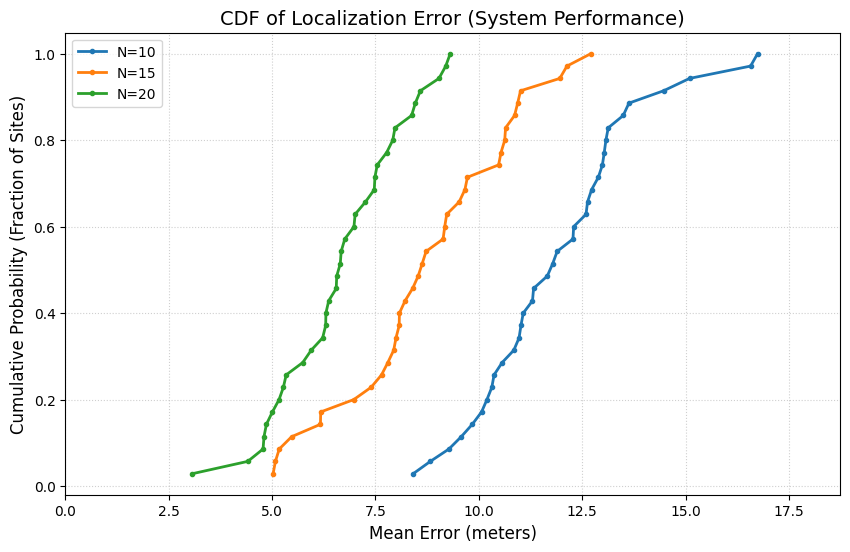

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# --- 1. יצירת דאטה דמה להדגמה (החליפי זאת בנתונים שלך) ---
# נניח שיש לך רשימה של שגיאות לכל N מכל ה-35 אתרים
np.random.seed(42)
n_sites = 35

# ADD YOUR CODE HERE
df = pd.DataFrame(results_list) 

# --- 2. גרף Box Plot (השוואת התפלגויות) ---
plt.figure(figsize=(10, 6))
sns.boxplot(x='N_labeled', y='Error', data=df, palette="Set2", width=0.5)
sns.swarmplot(x='N_labeled', y='Error', data=df, color=".25", size=4, alpha=0.6) # מוסיף את הנקודות עצמן לרקע

plt.title('Distribution of Localization Errors Across 35 Sites', fontsize=14)
plt.xlabel('Number of Labeled Points (N)', fontsize=12)
plt.ylabel('Mean Error (meters)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# --- 3. גרף CDF (התפלגות מצטברת) ---
plt.figure(figsize=(10, 6))

for n in [10, 15, 20]:
    # שליפת השגיאות עבור ה-N הנוכחי
    errors = df[df['N_labeled'] == n]['Error'].sort_values()
    # חישוב ה-Y (אחוזים מ-0 עד 1)
    y_vals = np.arange(1, len(errors) + 1) / len(errors)
    
    plt.plot(errors, y_vals, marker='.', linestyle='-', linewidth=2, label=f'N={n}')

plt.title('CDF of Localization Error (System Performance)', fontsize=14)
plt.xlabel('Mean Error (meters)', fontsize=12)
plt.ylabel('Cumulative Probability (Fraction of Sites)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.xlim(0, df['Error'].max() + 2) # קצת רווח בצד ימין
plt.show()